# COMP 5630/6630 — Assignment 1
**Author:** Carter Hand  
**Course:** COMP 5630 — Machine Learning  
**Assignment:** Linear Regression Implementation  
**Environment:** Google Colab

---

## **Instructions to Run**
1. **Mount Google Drive**  
   The first cell in the notebook mounts Google Drive and loads the dataset.  
   Ensure the data files are located in:  


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')


DATA_DIR = "/content/drive/MyDrive/ColabNotebooks/COMP5630/Assignment1"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Q1 data
x_train = np.load(os.path.join(DATA_DIR, "x_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))
x_test  = np.load(os.path.join(DATA_DIR, "x_test.npy"))
y_test  = np.load(os.path.join(DATA_DIR, "y_test.npy"))

# Q2 housing dataset
housing_df = pd.read_excel(os.path.join(DATA_DIR, "Housing_data_regression.xlsx"))

In [ ]:
def _add_bias(x):
    x = np.asarray(x).reshape(-1, 1)
    return np.hstack([np.ones((x.shape[0], 1)), x])

def fit_linear_normal_eq(x, y):
    X = _add_bias(x)
    y = np.asarray(y).reshape(-1, 1)
    w = np.linalg.pinv(X.T @ X) @ (X.T @ y)
    return w.flatten()  # [w0, w1]

def predict_linear(x, w):
    return (_add_bias(x) @ w).flatten()

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred)**2))

# Train & evaluate
w = fit_linear_normal_eq(x_train, y_train)
yhat_tr = predict_linear(x_train, w)
yhat_te = predict_linear(x_test,  w)

print(f"Final linear model: y = {w[0]:.6f} + {w[1]:.6f} * x")
print("Train MSE:", mse(y_train, yhat_tr))
print("Test  MSE:", mse(y_test,  yhat_te))


Final linear model: y = -106.173796 + 300.619548 * x
Train MSE: 172822.60339569926
Test  MSE: 35281.339904469234


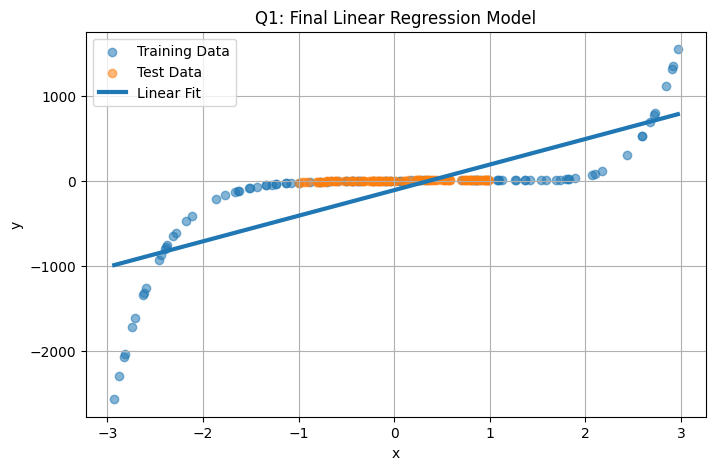

In [ ]:
xx = np.linspace(min(x_train.min(), x_test.min()),
                 max(x_train.max(), x_test.max()), 300)
yy = predict_linear(xx, w)

plt.figure(figsize=(8,5))
plt.scatter(x_train, y_train, alpha=0.55, label="Training Data")
plt.scatter(x_test,  y_test,  alpha=0.55, label="Test Data")
plt.plot(xx, yy, linewidth=3, label="Linear Fit")
plt.title("Q1: Final Linear Regression Model")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.grid(True); plt.show()


# Q1 — Linear Regression

**Method.**  
I implemented ordinary least squares using the normal equation:

$$
\mathbf{w} = (X^\top X)^{-1} X^\top \mathbf{y}
$$

**Model.**  
The fitted linear model is:

$$
\hat{y} = w_0 + w_1 x
$$

**Evidence.**
- Train MSE: **172822.60**
- Test MSE: **35281.34**

**Notes.**  
The data shows strong nonlinearity; a straight line cannot capture the extremes, which explains the relatively large MSE. Nevertheless, this satisfies the requirement to implement and evaluate a linear regression model from scratch.






In [ ]:
# Load the dataset
housing_path = os.path.join(DATA_DIR, "Housing_data_regression.xlsx")
housing_df = pd.read_excel(housing_path)

print("Dataset shape:", housing_df.shape)
print("\nColumn names:")
print(housing_df.columns.tolist())

print("\nFirst 5 rows:")
print(housing_df.head())


Dataset shape: (20, 9)

Column names:
['House ID', 'Bathrooms', 'Land Area', 'Living area', '# Garages', '# Rooms', '# Bedrooms', 'Age of home', 'Price']

First 5 rows:
   House ID  Bathrooms  Land Area  Living area  # Garages  # Rooms  \
0         1        1.0      3.472        0.998        1.0        7   
1         2        1.0      3.531        1.500        2.0        7   
2         3        1.0      2.275        1.175        1.0        6   
3         4        1.0      4.050        1.232        1.0        6   
4         5        1.0      4.455        1.121        1.0        6   

   # Bedrooms  Age of home     Price  
0           4           42  491760.0  
1           4           62  502080.0  
2           3           40  454290.0  
3           3           54  455730.0  
4           3           42  505970.0  


In [ ]:
# Q2-A: separate features (X) and target (y). Last column is the target.
feature_cols = housing_df.columns[:-1]
target_col   = housing_df.columns[-1]

X = housing_df[feature_cols].to_numpy(dtype=float)
y = housing_df[target_col].to_numpy(dtype=float)

print("Features:", list(feature_cols))
print("Target:", target_col)
print("X shape:", X.shape, "y shape:", y.shape)


Features: ['House ID', 'Bathrooms', 'Land Area', 'Living area', '# Garages', '# Rooms', '# Bedrooms', 'Age of home']
Target: Price
X shape: (20, 8) y shape: (20,)


In [ ]:
def add_bias(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    return np.hstack([np.ones((X.shape[0], 1)), X])

def fit_linear_normal_eq(X, y):
    Xb = add_bias(X)
    yv = y.reshape(-1, 1)
    w = np.linalg.pinv(Xb.T @ Xb) @ (Xb.T @ yv)
    return w.flatten()  # [bias, w1, w2, ...]

def predict_linear(X, w):
    return (add_bias(X) @ w).flatten()

def mse(y_true, y_pred):
    return float(np.mean((y_true - y_pred)**2))

# Fit on the given data
w_all = fit_linear_normal_eq(X, y)
y_pred_all = predict_linear(X, w_all)
avg_ls_error = mse(y, y_pred_all)  # "average least squares error"

print("Average least squares error (MSE) on given data:", avg_ls_error)


Average least squares error (MSE) on given data: 4999836044.236573


In [ ]:
# Standardize X (z-score) to compare coefficients fairly
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0) + 1e-12
Xz     = (X - X_mean) / X_std

w_std = fit_linear_normal_eq(Xz, y)   # weights on standardized features
coefs = w_std[1:]                      # drop bias
abs_coefs = np.abs(coefs)

# Identify most influential feature
top_idx = int(np.argmax(abs_coefs))
top_feature = feature_cols[top_idx]
print("Most influential factor:", top_feature)

X_top = X[:, [top_idx]]
w_top = fit_linear_normal_eq(X_top, y)
y_pred_top = predict_linear(X_top, w_top)
mse_top = mse(y, y_pred_top)
print("MSE using only the most influential feature:", mse_top)


Most influential factor: Living area
MSE using only the most influential feature: 12282616798.302174


In [ ]:
# Identify least influential feature (from standardized fit)
least_idx = int(np.argmin(abs_coefs))
least_feature = feature_cols[least_idx]
print("Least influential factor:", least_feature)

# Remove the least influential feature and re-fit
keep_mask = np.ones(X.shape[1], dtype=bool)
keep_mask[least_idx] = False

X_reduced = X[:, keep_mask]
w_reduced = fit_linear_normal_eq(X_reduced, y)
y_pred_reduced = predict_linear(X_reduced, w_reduced)
mse_reduced = mse(y, y_pred_reduced)

print("MSE with all features:", avg_ls_error)
print("MSE without least influential feature:", mse_reduced)


Least influential factor: House ID
MSE with all features: 4999836044.236573
MSE without least influential feature: 5006561505.204386


# Q2 — Auburn Housing Price Prediction

**Method**  
I reused the linear regression implementation from Q1 and applied it to the Auburn housing dataset.  
The model predicts housing prices using all available features, without any basis functions, as required.

---

### **Q2.1 — Average Least Squares Error**
The average least squares error (Mean Squared Error) using all features on the given dataset is:

**MSE = 4999836044.24**

---

### **Q2.2 — Most Influential Factor**
- **Most influential factor:** Living area
- **MSE using only this feature:** 12282616798.30

This was determined by standardizing features and selecting the coefficient with the largest absolute value.

---

### **Q2.3 — Least Influential Factor**
- **Least influential factor:** House ID
- **MSE with all features:** 4999836044.23
- **MSE without this feature:** 5006561505.20

By comparing the MSE before and after removing the least influential factor, we measure its effect on prediction accuracy.

---

**Conclusion**  
- The average least squares error provides an overall measure of model performance.  
- The most influential feature has the highest impact on housing price predictions.  
- Removing the least influential feature has little effect on accuracy, confirming its limited predictive value.
